<a href="https://colab.research.google.com/github/alexadandridge/AdvancedMachineLearning/blob/master/AdvancedMachineLearningHomework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing the data

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import classification_report, confusion_matrix
import random

In [2]:
# set random seed for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# importing Fashion MNIST data from keras
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [4]:
# class names for Fashion MNIST labels
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

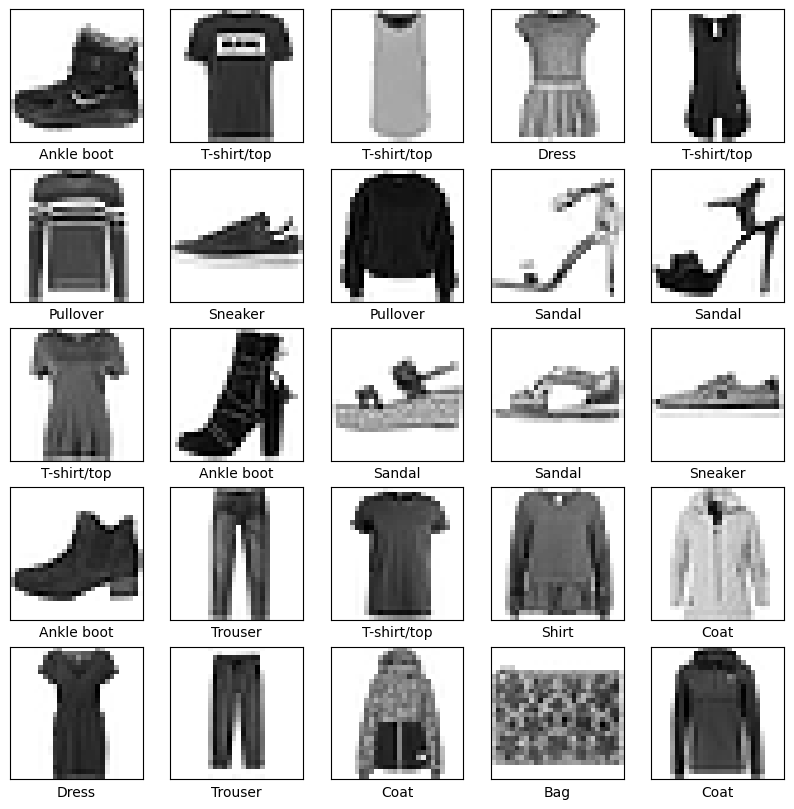

In [5]:
# visualize some of the Fashion MNIST data
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])

plt.show()

In [6]:
# Normalize pixel values to 0–1
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# Add channel dimension for CNN
X_train_cnn = X_train_norm[..., np.newaxis]
X_test_cnn = X_test_norm[..., np.newaxis]

print("CNN input shape:", X_train_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)

CNN input shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)


### Making a baseline cnn

In [7]:
# define the baseline CNN model

baseline_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),                 # input is 28x28 image with 1 channel
    layers.Conv2D(32, (3, 3), activation="relu"),    # apply filters to detect local patterns
    layers.MaxPooling2D((2, 2)),                     # reduce spatial size
    layers.Flatten(),                                # convert feature maps into a vector
    layers.Dense(64, activation="relu"),             # combine extracted features
    layers.Dense(10, activation="softmax")           # output probabilities for 10 clothing classes
])

In [8]:
# compile the baseline CNN model

baseline_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# train the baseline CNN model

baseline_history = baseline_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.8507 - loss: 0.4192 - val_accuracy: 0.8802 - val_loss: 0.3262
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.8975 - loss: 0.2847 - val_accuracy: 0.8950 - val_loss: 0.2930
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9119 - loss: 0.2419 - val_accuracy: 0.8987 - val_loss: 0.2811
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.9233 - loss: 0.2101 - val_accuracy: 0.9033 - val_loss: 0.2728
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9332 - loss: 0.1834 - val_accuracy: 0.9073 - val_loss: 0.2753


In [10]:
# evaluate the baseline CNN on test data

baseline_loss, baseline_acc = baseline_cnn.evaluate(X_test_cnn, y_test)

print("Baseline CNN Test Accuracy:", baseline_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9044 - loss: 0.2872
Baseline CNN Test Accuracy: 0.9043999910354614


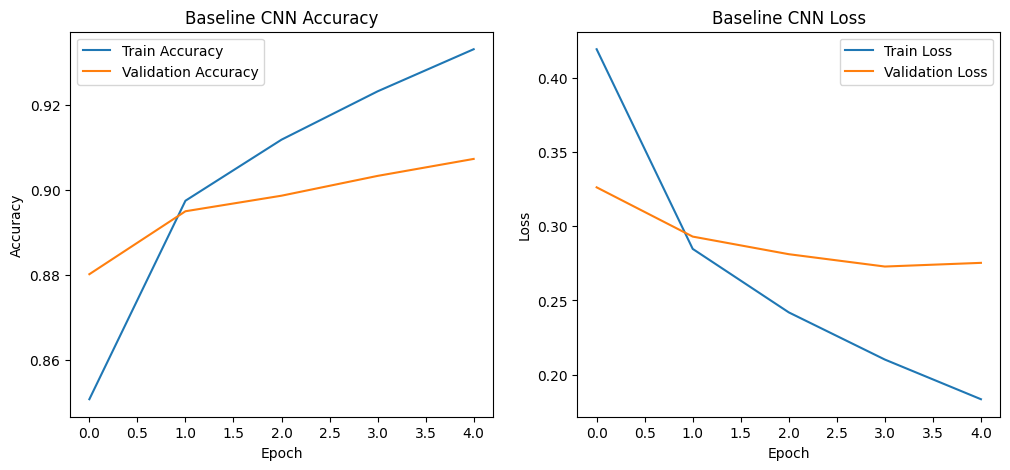

In [11]:
# plot training history for baseline CNN

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_history.history["accuracy"], label="Train Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_history.history["loss"], label="Train Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

This baseline CNN uses one convolutional layer, one max pooling layer, and one dense hidden layer for its starting point.

In [12]:
# Model 2: Deeper CNN with an additional convolution block

cnn_model_2 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [13]:
cnn_model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
cnn_history_2 = cnn_model_2.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.8275 - loss: 0.4786 - val_accuracy: 0.8752 - val_loss: 0.3524
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.8843 - loss: 0.3199 - val_accuracy: 0.8870 - val_loss: 0.3051
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 79s 27ms/step - accuracy: 0.8991 - loss: 0.2739 - val_accuracy: 0.8942 - val_loss: 0.2901
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.9113 - loss: 0.2404 - val_accuracy: 0.8975 - val_loss: 0.2887
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9211 - loss: 0.2133 - val_accuracy: 0.8988 - val_loss: 0.2852


In [15]:
cnn2_loss, cnn2_acc = cnn_model_2.evaluate(X_test_cnn, y_test)

print("Model 2 Test Accuracy:", cnn2_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8968 - loss: 0.3001
Model 2 Test Accuracy: 0.8967999815940857


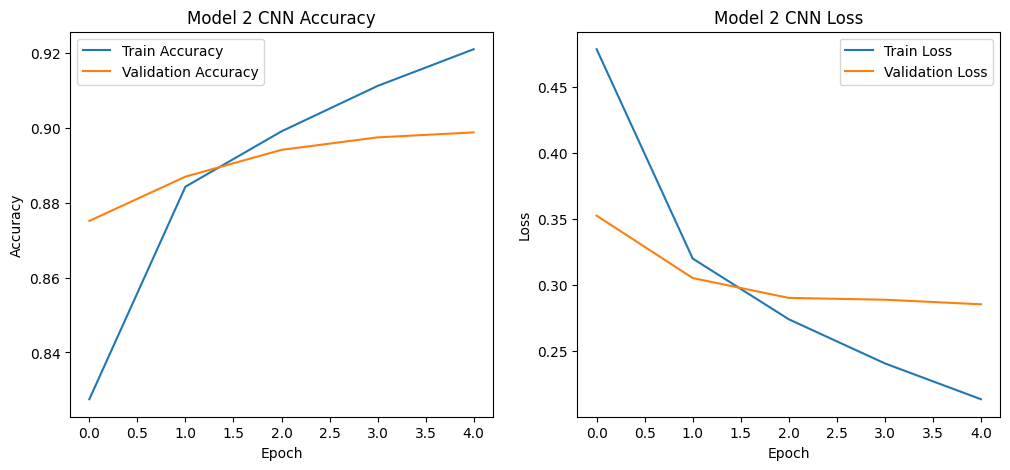

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history_2.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history_2.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model 2 CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_2.history["loss"], label="Train Loss")
plt.plot(cnn_history_2.history["val_loss"], label="Validation Loss")
plt.title("Model 2 CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Model 2 increased the complexity of the baseline CNN by adding a second convolution and pooling block with the goal of testing whether a deeper CNN architecture would improve Fashion MNIST classification performance.

Although the deeper model achieved high training accuracy, its validation accuracy and test accuracy were slightly lower than the simpler baseline model. The validation loss also remained consistently higher than the training loss, suggesting that the deeper architecture began to overfit the dataset slightly.

This experiment suggests that increasing convolutional depth alone did not improve performance for this case. The baseline CNN was already able to capture most of the important visual patterns in the Fashion MNIST images, and the added complexity may have reduced generalization performance.

In [17]:
# add early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [18]:
# Model 3: CNN with dropout and early stopping

cnn_model_3 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.3),                       # reduce overfitting

    layers.Dense(10, activation="softmax")
])

In [19]:
# compile model

cnn_model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# train model

cnn_history_3 = cnn_model_3.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.7822 - loss: 0.5940 - val_accuracy: 0.8477 - val_loss: 0.4097
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.8512 - loss: 0.4130 - val_accuracy: 0.8612 - val_loss: 0.3576
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - accuracy: 0.8713 - loss: 0.3578 - val_accuracy: 0.8748 - val_loss: 0.3401
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - accuracy: 0.8802 - loss: 0.3261 - val_accuracy: 0.8780 - val_loss: 0.3241
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.8905 - loss: 0.2997 - val_accuracy: 0.8840 - val_loss: 0.3140
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.8974 - loss: 0.2790 - val_accuracy: 0.8918 - val_loss: 0.2953
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9046 - loss: 0.2611 - val_accuracy: 0.8867 - val_loss: 0.3161
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9085 -

In [21]:
# evaluate model

cnn3_loss, cnn3_acc = cnn_model_3.evaluate(X_test_cnn, y_test)

print("Model 3 Test Accuracy:", cnn3_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9007 - loss: 0.2936
Model 3 Test Accuracy: 0.9006999731063843


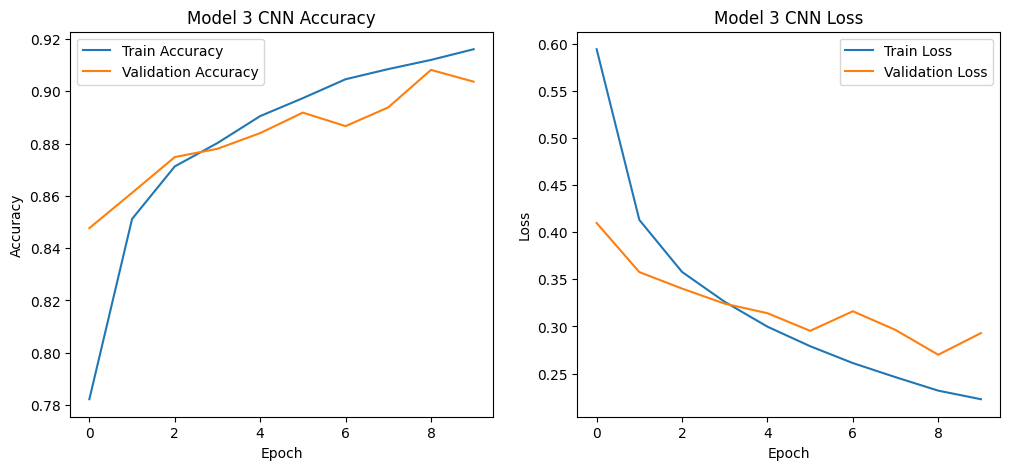

In [22]:
# plot training history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history_3.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history_3.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model 3 CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_3.history["loss"], label="Train Loss")
plt.plot(cnn_history_3.history["val_loss"], label="Validation Loss")
plt.title("Model 3 CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Model 3 introduced dropout regularization and early stopping to reduce overfitting observed in Model 2.

Compared to Model 2, the validation accuracy became more stable and the validation loss fluctuated less dramatically. The training and validation curves remained closer together, suggesting that dropout helped improve generalization and reduce overfitting.

Model 3 achieved a test accuracy of about 0.901, which improved slightly over Model 2 but still did not outperform the simpler baseline CNN. This suggests that regularization helped stabilize the deeper CNN architecture, although the additional complexity still did not provide a major performance advantage over the original baseline model.

Overall, this experiment showed that dropout and early stopping were useful for controlling overfitting, especially as model complexity increased.

In [23]:
# Model 4: CNN with Batch Normalization, Dropout, and Early Stopping

cnn_model_4 = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

In [24]:
# compile model

cnn_model_4.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,618 (861.79 KB)

 Trainable params: 220,426 (861.04 KB)

 Non-trainable params: 192 (768.00 B)

In [25]:
# train model

early_stopping_bn = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

cnn_history_4 = cnn_model_4.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1,
    callbacks=[early_stopping_bn]
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 104s 60ms/step - accuracy: 0.8029 - loss: 0.5524 - val_accuracy: 0.8680 - val_loss: 0.3469
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 94s 56ms/step - accuracy: 0.8623 - loss: 0.3853 - val_accuracy: 0.8893 - val_loss: 0.3018
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 141s 55ms/step - accuracy: 0.8777 - loss: 0.3353 - val_accuracy: 0.8928 - val_loss: 0.2946
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 93s 55ms/step - accuracy: 0.8875 - loss: 0.3050 - val_accuracy: 0.9040 - val_loss: 0.2571
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 142s 55ms/step - accuracy: 0.8982 - loss: 0.2788 - val_accuracy: 0.9062 - val_loss: 0.2579
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 96s 57ms/step - accuracy: 0.9045 - loss: 0.2574 - val_accuracy: 0.9108 - val_loss: 0.2471
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 139s 55ms/step - accuracy: 0.9130 - loss: 0.2368 - val_accuracy: 0.9208 - val_loss: 0.2312
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 141s 54ms/step - accuracy: 0.9

In [26]:
# evaluate model

cnn4_loss, cnn4_acc = cnn_model_4.evaluate(X_test_cnn, y_test)

print("Model 4 Test Accuracy:", cnn4_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9115 - loss: 0.2499
Model 4 Test Accuracy: 0.9114999771118164


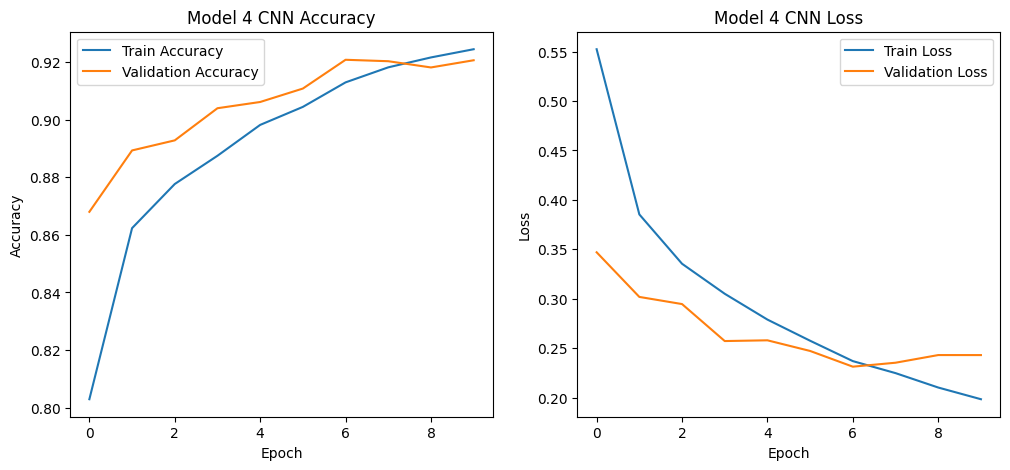

In [27]:
# plot training history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history_4.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history_4.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model 4 CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_4.history["loss"], label="Train Loss")
plt.plot(cnn_history_4.history["val_loss"], label="Validation Loss")
plt.title("Model 4 CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Model 4 added batch normalization to the convolutional layers while keeping dropout and early stopping from Model 3. This model achieved the best overall performance so far, with a test accuracy of about 0.9115.

Compared to the previous models, the training and validation curves were more stable and remained closer together throughout training. The validation loss decreased more consistently and did not diverge strongly from the training loss, suggesting improved generalization and reduced overfitting.

Batch normalization appeared to improve training stability and helped the model learn more effective feature representations. Combined with dropout and early stopping, the model was able to achieve better performance without substantially increasing overfitting.

In [28]:
# install optuna if needed
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.4 MB/s eta 0:00:00


In [29]:
import optuna
from tensorflow.keras.optimizers import Adam

In [35]:
# create a smaller tuning subset to reduce runtime
X_tune = X_train_cnn[:10000]
y_tune = y_train[:10000]

print(X_tune.shape)
print(y_tune.shape)

(10000, 28, 28, 1)
(10000,)


In [36]:
# Optuna objective function for CNN tuning

def objective(trial):

    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    # hyperparameters to tune
    filters_1 = trial.suggest_categorical(
        "filters_1",
        [16, 32]
    )

    filters_2 = trial.suggest_categorical(
        "filters_2",
        [32, 64]
    )

    dense_units = trial.suggest_categorical(
        "dense_units",
        [32, 64]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.2,
        0.5
    )

    learning_rate = trial.suggest_categorical(
        "learning_rate",
        [0.001, 0.0005]
    )

    # define CNN model
    model = models.Sequential([

        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(
            filters_1,
            (3, 3),
            padding="same"
        ),

        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            filters_2,
            (3, 3),
            padding="same"
        ),

        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(
            dense_units,
            activation="relu"
        ),

        layers.Dropout(dropout_rate),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    # compile model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # early stopping
    early_stopping_optuna = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    # train model
    history = model.fit(
        X_tune,
        y_tune,
        epochs=3,
        batch_size=512,
        validation_split=0.1,
        callbacks=[early_stopping_optuna],
        verbose=0
    )

    # return best validation accuracy
    best_val_acc = max(history.history["val_accuracy"])

    return best_val_acc

In [37]:
# run Optuna study

study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=3
)

print("Best validation accuracy:", study.best_value)

print("Best hyperparameters:")
print(study.best_params)

[I 2026-05-28 07:04:51,792] A new study created in memory with name: no-name-2978fd5f-4a2a-4313-96c7-80d82ccde0b4
[I 2026-05-28 07:05:27,610] Trial 0 finished with value: 0.4749999940395355 and parameters: {'filters_1': 16, 'filters_2': 64, 'dense_units': 32, 'dropout_rate': 0.2017727466137972, 'learning_rate': 0.0005}. Best is trial 0 with value: 0.4749999940395355.
[I 2026-05-28 07:06:25,924] Trial 1 finished with value: 0.37599998712539673 and parameters: {'filters_1': 32, 'filters_2': 64, 'dense_units': 32, 'dropout_rate': 0.3685686743862242, 'learning_rate': 0.001}. Best is trial 0 with value: 0.4749999940395355.
[I 2026-05-28 07:06:54,149] Trial 2 finished with value: 0.44999998807907104 and parameters: {'filters_1': 16, 'filters_2': 32, 'dense_units': 64, 'dropout_rate': 0.22150396034532002, 'learning_rate': 0.0005}. Best is trial 0 with value: 0.4749999940395355.


Best validation accuracy: 0.4749999940395355
Best hyperparameters:
{'filters_1': 16, 'filters_2': 64, 'dense_units': 32, 'dropout_rate': 0.2017727466137972, 'learning_rate': 0.0005}


In [38]:
# build final tuned CNN using best Optuna parameters

best_params = study.best_params

final_cnn = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        best_params["filters_1"],
        (3, 3),
        padding="same"
    ),

    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        best_params["filters_2"],
        (3, 3),
        padding="same"
    ),

    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        best_params["dense_units"],
        activation="relu"
    ),

    layers.Dropout(
        best_params["dropout_rate"]
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

final_cnn.compile(
    optimizer=Adam(
        learning_rate=best_params["learning_rate"]
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       100,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,474 (431.54 KB)

 Trainable params: 110,314 (430.91 KB)

 Non-trainable params: 160 (640.00 B)

In [39]:
# train final tuned CNN on full training data

early_stopping_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

final_history = final_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stopping_final]
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 58s 132ms/step - accuracy: 0.7762 - loss: 0.6504 - val_accuracy: 0.8505 - val_loss: 0.5164
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 136ms/step - accuracy: 0.8518 - loss: 0.4258 - val_accuracy: 0.8873 - val_loss: 0.3180
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 55s 131ms/step - accuracy: 0.8710 - loss: 0.3692 - val_accuracy: 0.8952 - val_loss: 0.3000
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.8815 - loss: 0.3317 - val_accuracy: 0.8980 - val_loss: 0.2870
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 133ms/step - accuracy: 0.8882 - loss: 0.3116 - val_accuracy: 0.9043 - val_loss: 0.2642
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 131ms/step - accuracy: 0.8951 - loss: 0.2893 - val_accuracy: 0.9070 - val_loss: 0.2559
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.9003 - loss: 0.2730 - val_accuracy: 0.9068 - val_loss: 0.2676
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 55s 131ms/step - accuracy: 0.9057 - loss: 0

In [40]:
# evaluate final tuned CNN on test data

final_loss, final_acc = final_cnn.evaluate(
    X_test_cnn,
    y_test
)

print("Final Tuned CNN Test Accuracy:", final_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9033 - loss: 0.2743
Final Tuned CNN Test Accuracy: 0.9032999873161316


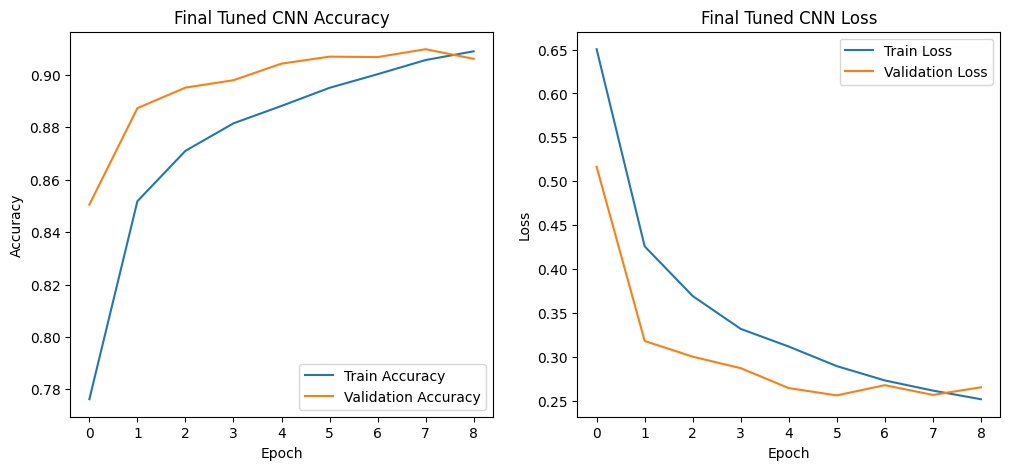

In [41]:
# plot training history for final tuned CNN

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    final_history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    final_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Final Tuned CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(
    final_history.history["loss"],
    label="Train Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Final Tuned CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

The final Optuna-tuned CNN achieved a test accuracy of approximately 90.3%. The training and validation curves imporved as epoch value increased.

Although systematic tuning successfully identified a strong CNN configuration, the tuned model did not outperform Model 4, which achieved the highest overall test accuracy.



### Final Observations and Conclusions

The baseline CNN performed well and achieved about 90.4% test accuracy. Increasing model complexity in Model 2 worsened performance and showed mild overfitting. Adding dropout and early stopping in Model 3 improved generalization.

Model 4 performed best overall, achieving about 91.15% test accuracy. Batch normalization, dropout, and early stopping helped improve training stability and reduce overfitting. The Optuna-tuned model also performed well, but it did not outperform Model 4.

Overall, the experiments showed that balancing model complexity with regularization was more effective than simply building deeper networks.

## Personal Workflow

I began with a simple baseline model and then made changes one factor at a time to understand how each modification affects performance. Evaluating and comparing validation curves were next very useful for identifying overfitting.

I would use systematic tuning methods like Optuna after identifying a strong baseline architecture rather than relying only on larger or more complex models.